# <b>Email Spam Detection & Explainable AI Platform</b>

## <b>MODEL TRAINING & EVALUATION</b>
The goal of this phase is to train multiple Machine Learning algorithms and identify the most suitable model for Email Spam Detection.

### Models Evaluated:

1. Multinomial Naive Bayes
2. Logistic Regression
3. Linear SVM
4. Random Forest

Evaluation Metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

The selected deployment model should provide the best balance between spam detection performance and reliability.

### <b> Step 1: Import Libraries</b>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from wordcloud import WordCloud
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
sns.set_style("whitegrid")

### <b> Step 2: Load the data</b>

#### Load Train-Test Data

The training and testing datasets generated during model preparation are loaded for evaluation.

In [4]:
# Load cleaned dataset
df = pd.read_csv(
    "../data/processed/email_cleaned.csv"
)

X_test = joblib.load("../models/X_test.pkl")
y_test = joblib.load("../models/y_test.pkl")

print("X_test Shape:", X_test.shape)
print("y_test Shape:", y_test.shape)

X_test Shape: (1146, 5006)
y_test Shape: (1146,)


### <b> Step 3: Load Model Results</b>

The performance metrics of all trained models are loaded for comparison.

In [3]:
results_df = pd.read_csv(
    "../models/model_results.csv"
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9878,0.9851,0.9635,0.9742,0.9992
1,Random Forest,0.9852,0.9813,0.9562,0.9686,0.9980
2,Linear SVM,0.9887,0.9815,0.9708,0.9761,0.9825
3,Naive Bayes,0.7269,0.4612,0.8467,0.5972,0.8329


### <b>Step 4: Model Performance Comparison</b>

The table below compares all trained models using multiple evaluation metrics.

In [4]:
results_df.style.background_gradient(
    cmap="Blues"
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.987800,0.985100,0.963500,0.974200,0.999200
1,Random Forest,0.985200,0.981300,0.956200,0.968600,0.998000
2,Linear SVM,0.988700,0.981500,0.970800,0.976100,0.982500
3,Naive Bayes,0.726900,0.461200,0.846700,0.597200,0.832900


#### Insight

- Logistic Regression achieved the highest ROC-AUC score.
- Linear SVM achieved the highest Accuracy.
- Linear SVM also achieved the highest Recall and F1 Score.
- Naive Bayes performed significantly worse than the other algorithms.

### <b>Step 5: Accuracy Comaprison </b>

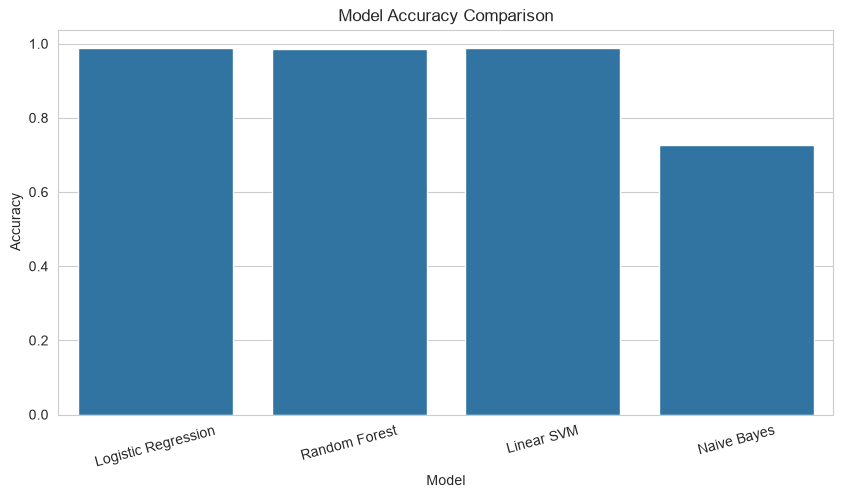

In [5]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.show()

#### Insight

Linear SVM achieved the highest classification accuracy among all evaluated models.

### <b>Step 6: Precision Comparison</b>

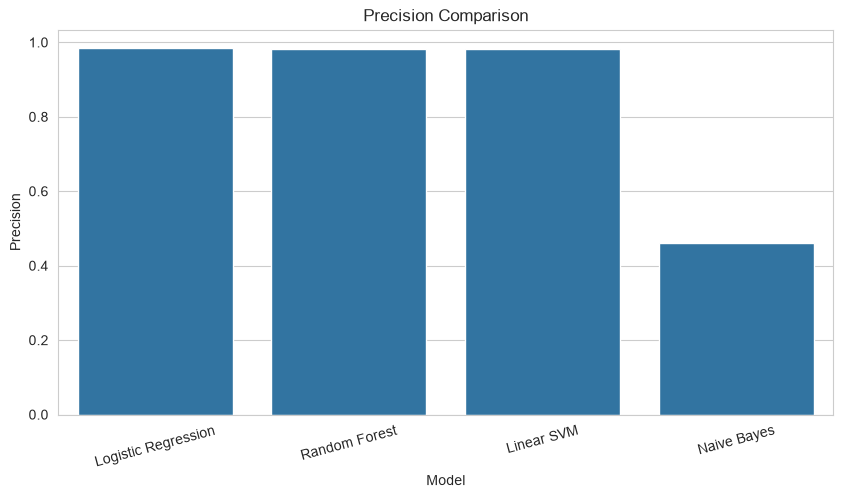

In [6]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=results_df,
    x="Model",
    y="Precision"
)

plt.title("Precision Comparison")
plt.xticks(rotation=15)
plt.show()

#### Insight

Logistic Regression achieved the highest precision score, indicating fewer false positives.

### <b>Step 7: Recall Comaprison</b>

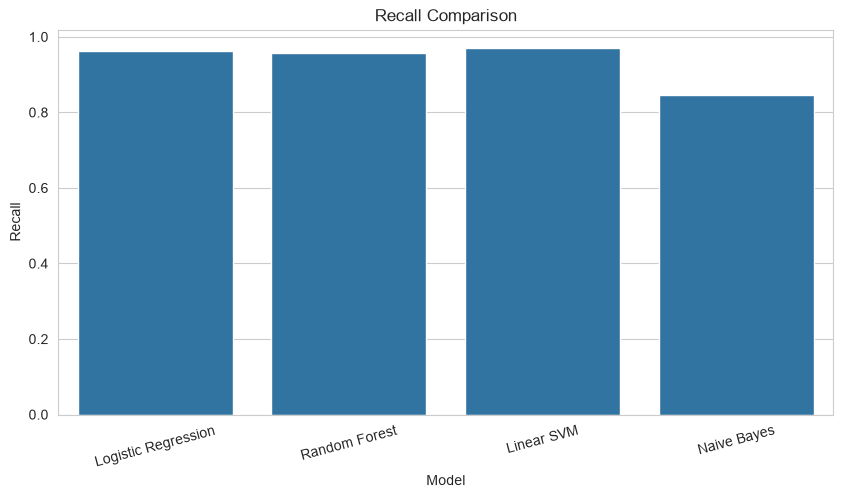

In [7]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=results_df,
    x="Model",
    y="Recall"
)

plt.title("Recall Comparison")
plt.xticks(rotation=15)
plt.show()

#### Insight

Linear SVM achieved the highest recall score, indicating better detection of spam emails.

### <b>Step 8: F1 Comaprison</b>

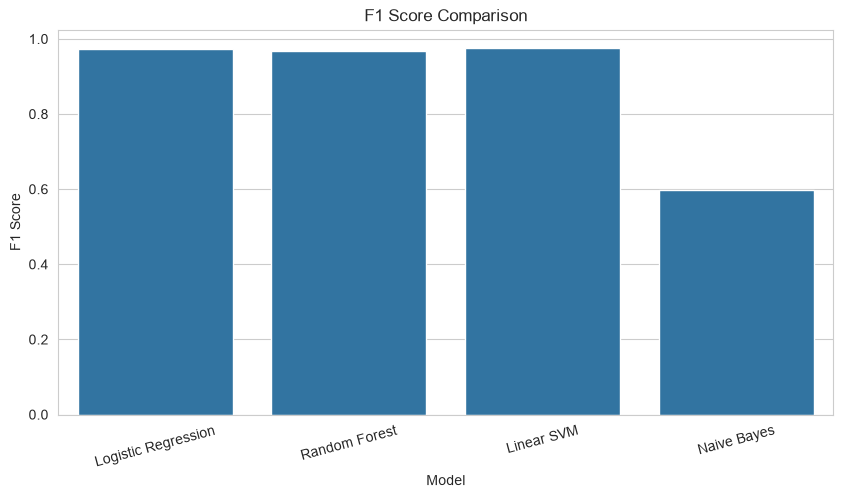

In [8]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score"
)

plt.title("F1 Score Comparison")
plt.xticks(rotation=15)
plt.show()

#### Insight

Linear SVM achieved the highest F1 Score, demonstrating the best balance between precision and recall.

### <b>Step 9: ROC-AUC Comparison</b>

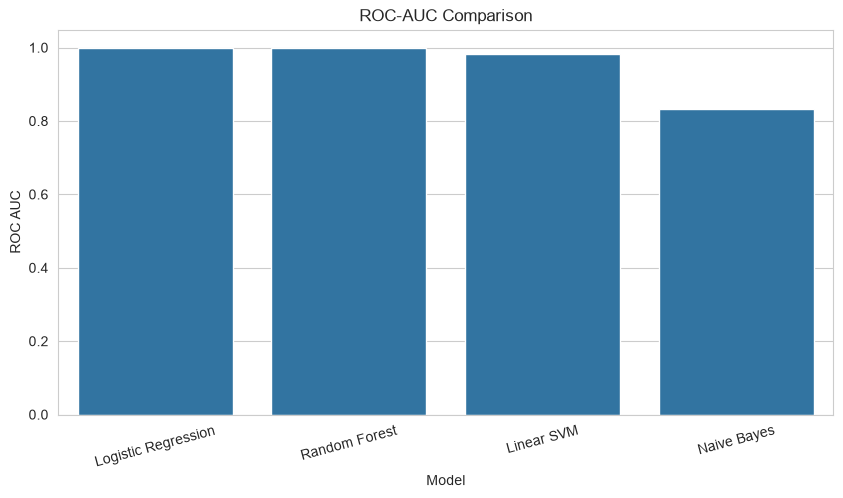

In [9]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=results_df,
    x="Model",
    y="ROC AUC"
)

plt.title("ROC-AUC Comparison")
plt.xticks(rotation=15)
plt.show()

### <b>Step 10: Final Model Selection</b>

#### Deployment Model Selection

Although Logistic Regression achieved the highest ROC-AUC score, Linear SVM demonstrated:

- Highest Accuracy
- Highest Recall
- Highest F1 Score

For an Email Spam Detection system, recall and F1 Score are particularly important because missing spam emails can negatively impact users.

Therefore, Linear SVM was selected as the deployment model.

### <b>Step 11: Load SVM Model</b>

In [ ]:
model = joblib.load("../models/linear_svm.pkl")
scaler = joblib.load("../models/scaler.pkl")
X_test_scaled = scaler.transform(X_test)
y_pred = model.predict(X_test_scaled)

### <b>Step 12: Confusion Matrix</b>

The confusion matrix provides a detailed view of prediction performance.

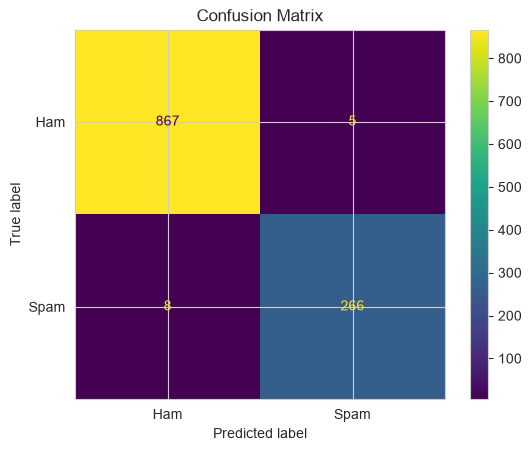

In [11]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.savefig(
    "../dashboard/assets/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Insight

The confusion matrix shows that the model correctly classified the majority of spam and ham emails with very few misclassifications.

### <b>Step 13: Classification Report</b>

Detailed classification metrics for each class.

In [12]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       872
           1       0.98      0.97      0.98       274

    accuracy                           0.99      1146
   macro avg       0.99      0.98      0.98      1146
weighted avg       0.99      0.99      0.99      1146



#### Insight

The Linear SVM model achieved strong precision, recall, and F1 scores across both classes, indicating excellent overall performance.

### <b>Step 14: Explainable AI (Feature Importance)</b>

Linear SVM coefficients can be used to identify the most influential words for spam classification.

In [13]:
feature_names = joblib.load("../models/feature_columns.pkl")
coef = model.coef_[0]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef
})

importance_df.head()

importance_df.to_csv(
    "../dashboard/data/model_coefficients.csv",
    index=False
)

#### <b>Top Spam Indicators</b>

In [14]:
top_spam = importance_df.sort_values(
    by="Coefficient",
    ascending=False
).head(20)

top_spam

,Feature,Coefficient
4231,subject,0.831205
3791,rolet,0.695581
4063,softwar,0.681340
1999,http,0.589414
2434,life,0.576501
656,click,0.560757
981,de,0.560376
4762,visit,0.550314
2715,medic,0.530757
2832,money,0.506973


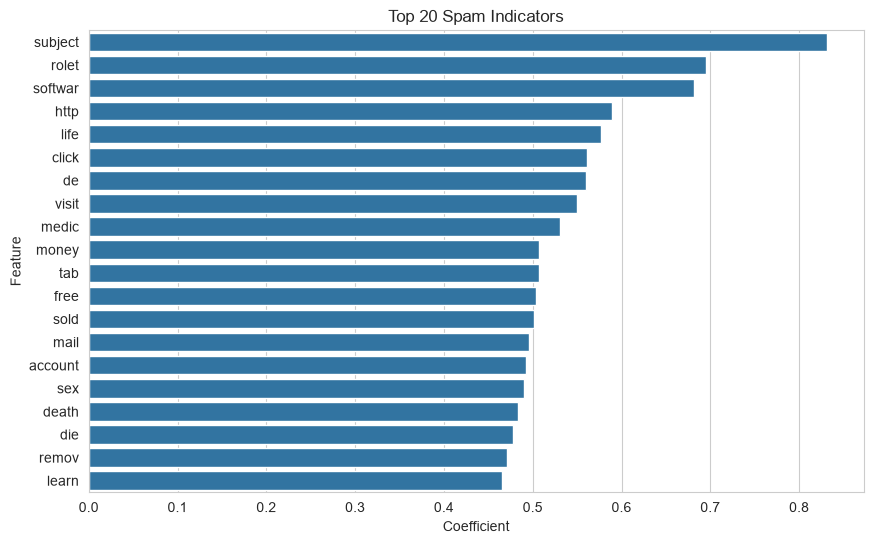

In [15]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_spam,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 20 Spam Indicators")
plt.show()

##### Insight

Words with positive coefficients strongly contribute to spam classification and represent common spam patterns.

#### <b>Spam Word Cloud</b>

This visualization highlights the most frequently occurring words in spam emails.

Larger words indicate higher frequency and greater importance within spam messages.

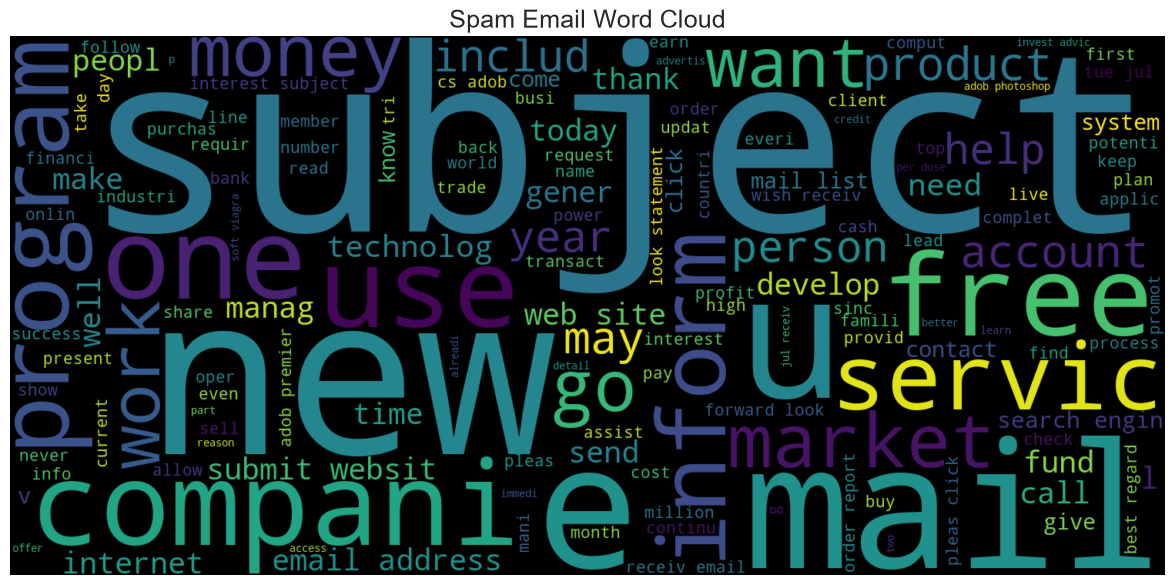

In [16]:
spam_text = " ".join(
    df[df["Category"] == 1]
    ["CleanMessage"]
)

spam_cloud = WordCloud(
    width=1500,
    height=700,
    background_color="black",
    colormap="viridis",
    max_words=150
).generate(spam_text)

plt.figure(figsize=(15,7))

plt.imshow(
    spam_cloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Spam Email Word Cloud",
    fontsize=18
)

plt.show()

##### Insight

- Spam emails are dominated by promotional and marketing-related vocabulary.
- Frequently occurring terms often include financial incentives, offers, rewards, and urgent call-to-action phrases.
- These patterns support the effectiveness of TF-IDF-based feature extraction.

#### <b>Top Ham Indicators</b>

In [17]:
top_ham = importance_df.sort_values(
    by="Coefficient",
    ascending=True
).head(20)

top_ham

,Feature,Coefficient
4731,vinc,-1.251131
1335,enron,-0.875867
4432,thank,-0.744310
3268,pl,-0.641048
3691,research,-0.614871
2269,kaminski,-0.605390
3154,password,-0.539278
264,attach,-0.525646
2014,hurrican,-0.524733
4039,site licens,-0.500744


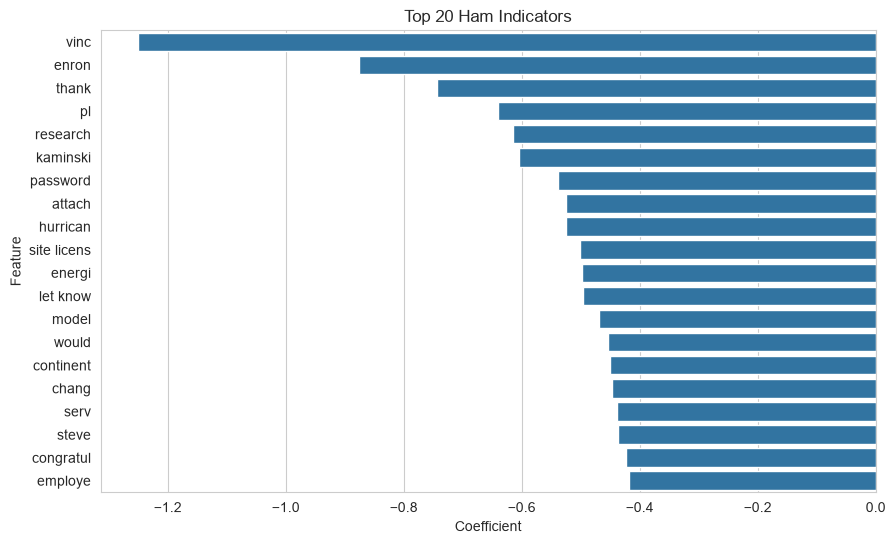

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_ham,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 20 Ham Indicators")

plt.show()

##### Insight

Words with negative coefficients are associated with legitimate email communication and reduce the probability of an email being classified as spam.

#### <b>Ham Word Cloud</b>

This visualization highlights the most common words appearing in legitimate emails.

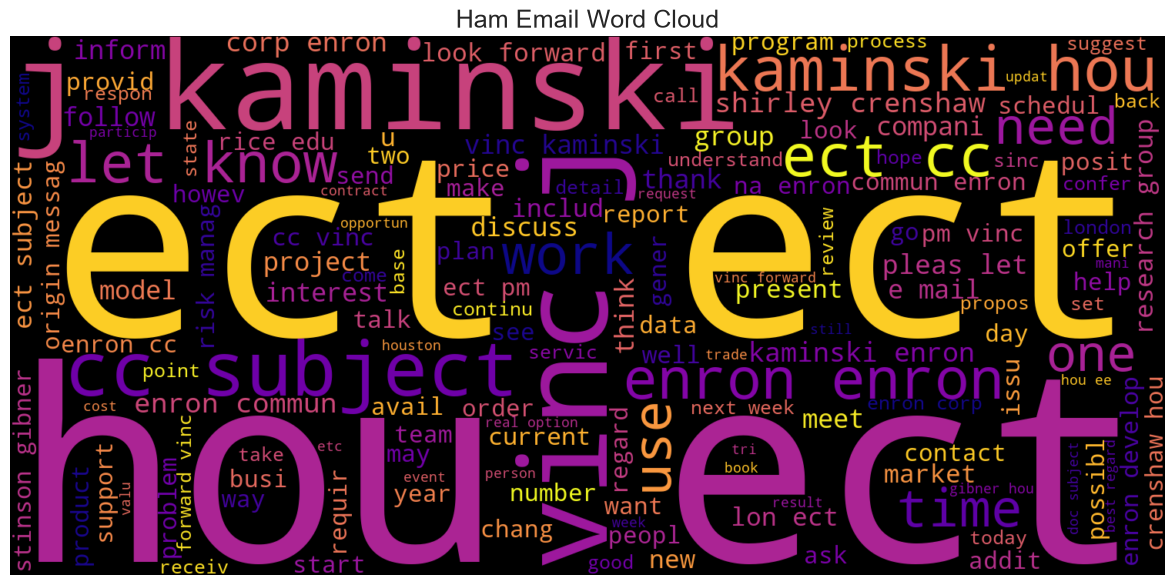

In [19]:
ham_text = " ".join(
    df[df["Category"] == 0]
    ["CleanMessage"]
)

ham_cloud = WordCloud(
    width=1500,
    height=700,
    background_color="black",
    colormap="plasma",
    max_words=150
).generate(ham_text)

plt.figure(figsize=(15,7))

plt.imshow(
    ham_cloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Ham Email Word Cloud",
    fontsize=18
)

plt.show()

##### Insight

- Ham emails contain communication-oriented vocabulary.
- Common words relate to meetings, discussions, project updates, scheduling, and workplace communication.
- The vocabulary differs substantially from spam emails, which explains the strong performance of text-based classifiers.

### <b> CONCLUSION</b>

#### Best ROC-AUC Model
- Logistic Regression

#### Best Overall Classification Model
- Linear SVM

#### Deployment Model
- Linear SVM

#### Final Performance (Linear SVM)

- Accuracy: 98.87%
- Precision: 98.15%
- Recall: 97.08%
- F1 Score: 97.61%

The model demonstrates excellent capability in identifying spam emails while maintaining a very low false positive rate.

The trained Linear SVM model was selected for deployment in the Email Spam Detection Dashboard.